In [16]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/alajmirawan/ecommercecustomers-csv/Ecommerce Customers')

Explore the Data

In [17]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [19]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


Data Cleaning

In [20]:
# Check missing values
df.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [22]:
# Remove non-numeric columns if they exist
df = df.drop(columns=['Email', 'Address', 'Avatar'], errors='ignore')

Feature Engineering

In [23]:
df['Spending per Session'] = df['Yearly Amount Spent'] / df['Avg. Session Length']

Visualization

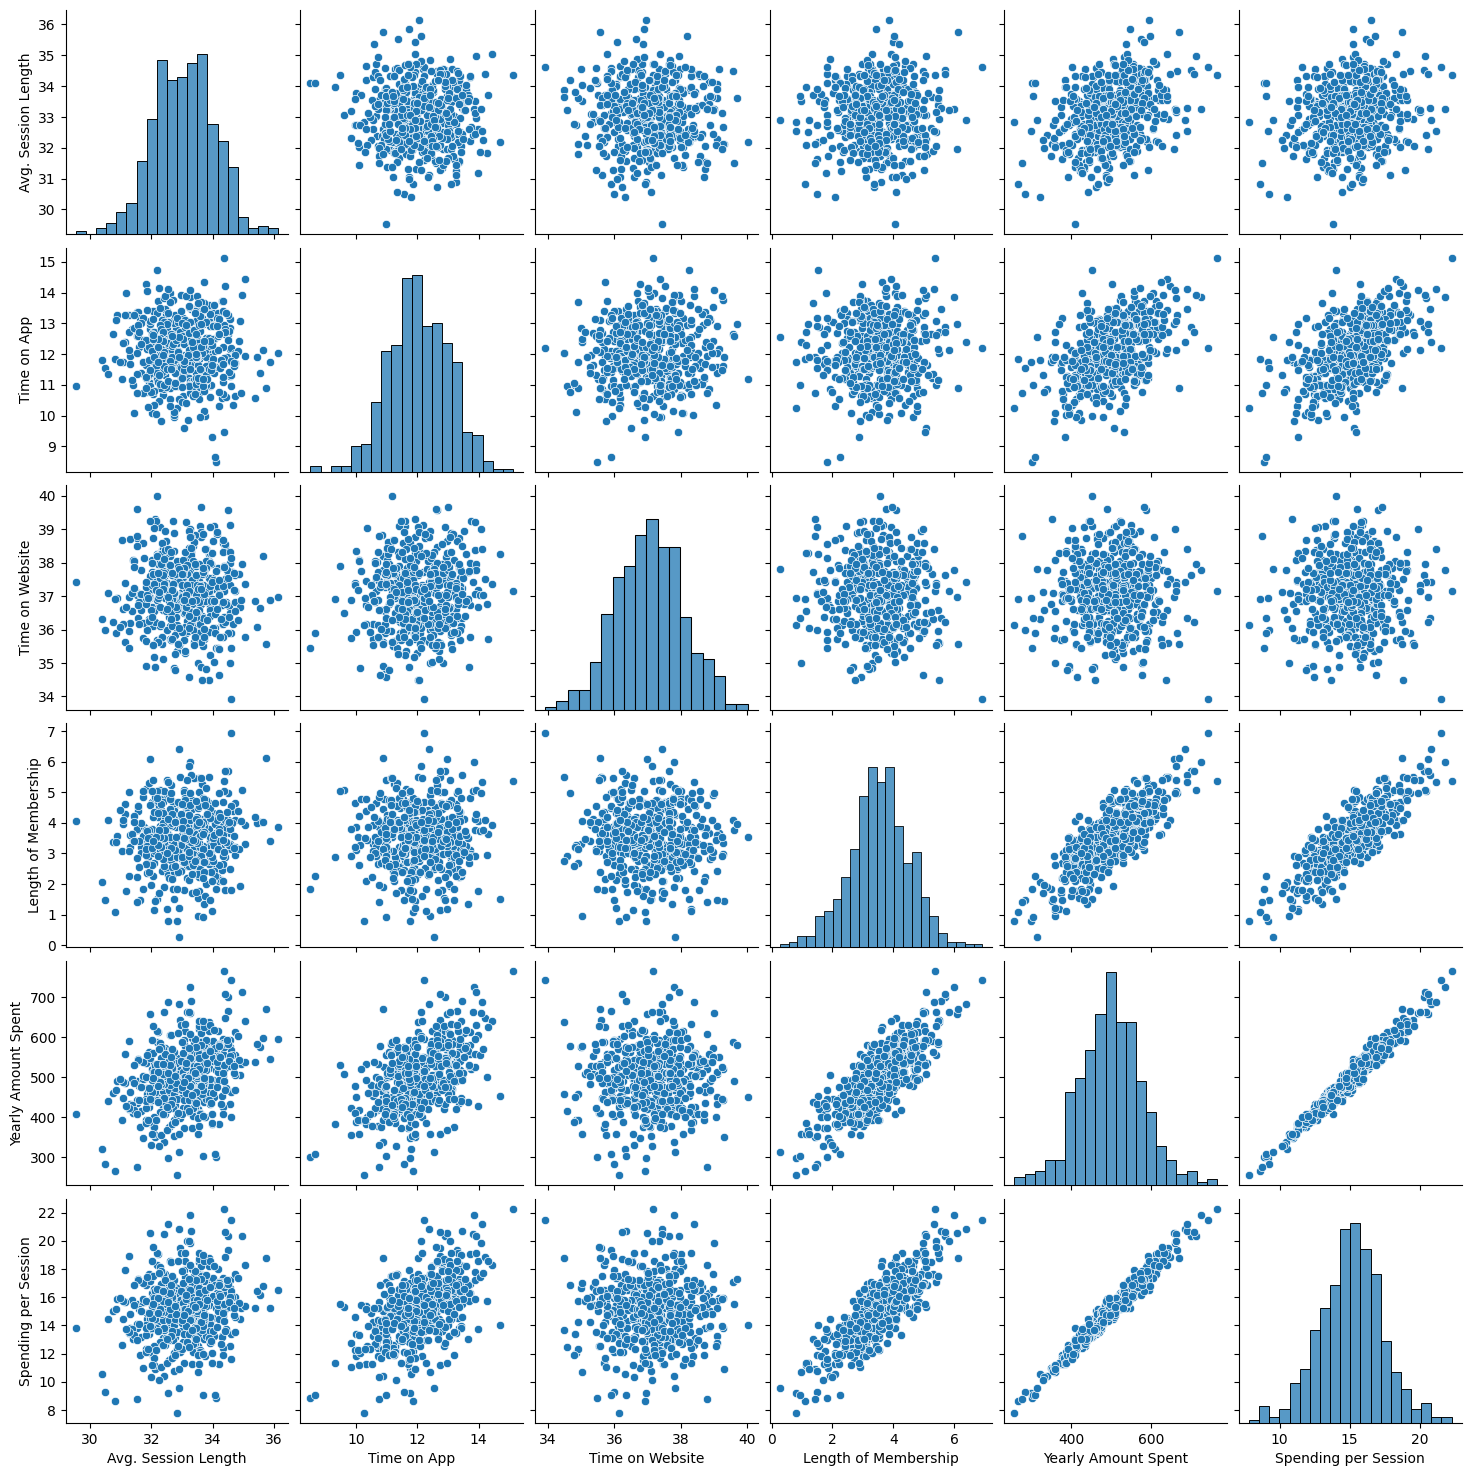

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)

<Axes: >

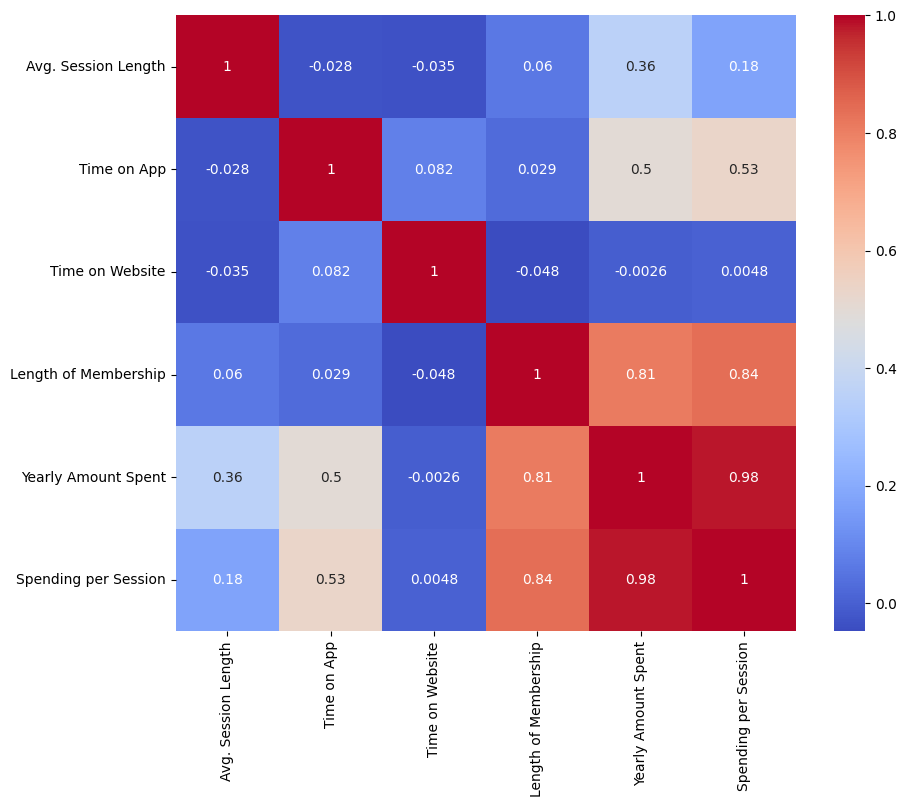

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

Prepare Data

In [27]:
X = df.drop('Yearly Amount Spent', axis=1)
y = df['Yearly Amount Spent']

Train/Test Split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Train Model

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Predictions

In [38]:
predictions = model.predict(X_test)

Evaluation

In [39]:
from sklearn import metrics
import numpy as np

print("MAE:", metrics.mean_absolute_error(y_test, predictions))
print("MSE:", metrics.mean_squared_error(y_test, predictions))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 1.590623010698743
MSE: 5.250289844782833
RMSE: 2.291351095921974


Visualization Results

Text(0.5, 1.0, 'Actual vs Predicted')

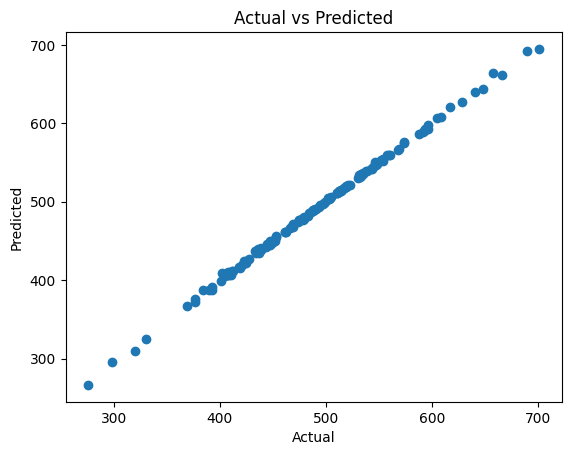

In [40]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

Residual Analysis

Text(0.5, 1.0, 'Residual Distribution')

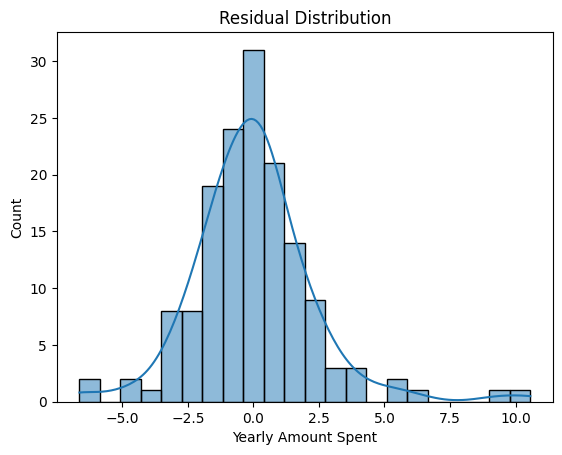

In [41]:
sns.histplot(y_test - predictions, kde=True)
plt.title("Residual Distribution")

Model Interpretation

In [42]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Session Length,15.917395
Time on App,2.720927
Time on Website,-0.139294
Length of Membership,4.122955
Spending per Session,30.879631


Conclusion
The dataset was loaded and explored successfully. It contained no missing values, and irrelevant categorical features were removed. A Linear Regression model was trained and evaluated. The model performed well with low error values, and feature analysis showed the impact of each variable on customer spending.